In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.linear_model import Perceptron
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical


In [3]:
import os
import glob
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")

print("Path to dataset :", path)

Using Colab cache for faster access to the 'lgg-mri-segmentation' dataset.
Path to dataset : /kaggle/input/lgg-mri-segmentation


In [5]:
import os
os.listdir(path)

['kaggle_3m', 'lgg-mri-segmentation']

In [6]:
import pandas as pd
import glob
import os

data_dir = '/kaggle/input/lgg-mri-segmentation/kaggle_3m/'
# Get all file paths for images and masks
# The dataset structure is: patient_folder/image_name.tif and patient_folder/image_name_mask.tif
filenames = glob.glob(data_dir + '**/*.tif', recursive=True)

# Separate images from masks
# Masks always contain the string '_mask'
mask_files = [f for f in filenames if '_mask' in f]
image_files = [f for f in filenames if '_mask' not in f]

# Create a DataFrame
df = pd.DataFrame({
    'image_path': image_files,
    # This logic matches the image with its corresponding mask by adding '_mask' to the filename
    'mask_path': [f.replace('.tif', '_mask.tif') for f in image_files]
})

print(f"Total images found: {len(df)}")
df.head()

Total images found: 3929


,image_path,mask_path
0,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
1,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
2,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
3,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
4,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...


In [7]:
df

,image_path,mask_path
0,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
1,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
2,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
3,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
4,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
...,...,...
3924,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
3925,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
3926,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
3927,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3929 entries, 0 to 3928
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  3929 non-null   object
 1   mask_path   3929 non-null   object
dtypes: object(2)
memory usage: 61.5+ KB


In [9]:
# Load the patient metadata
patient_df = pd.read_csv(data_dir + 'data.csv')

# Let's see what's inside
print("Patient Data Shape:", patient_df.shape)
patient_df.head()

Patient Data Shape: (110, 18)


,Patient,RNASeqCluster,MethylationCluster,miRNACluster,CNCluster,RPPACluster,OncosignCluster,COCCluster,histological_type,neoplasm_histologic_grade,tumor_tissue_site,laterality,tumor_location,gender,age_at_initial_pathologic,race,ethnicity,death01
0,TCGA_CS_4941,2.0,4.0,2,2.0,NaN,3.0,2,1.0,2.0,1.0,3.0,2.0,2.0,67.0,3.0,2.0,1.0
1,TCGA_CS_4942,1.0,5.0,2,1.0,1.0,2.0,1,1.0,2.0,1.0,3.0,2.0,1.0,44.0,2.0,NaN,1.0
2,TCGA_CS_4943,1.0,5.0,2,1.0,2.0,2.0,1,1.0,2.0,1.0,1.0,2.0,2.0,37.0,3.0,NaN,0.0
3,TCGA_CS_4944,NaN,5.0,2,1.0,2.0,1.0,1,1.0,1.0,1.0,3.0,6.0,2.0,50.0,3.0,NaN,0.0
4,TCGA_CS_5393,4.0,5.0,2,1.0,2.0,3.0,1,1.0,2.0,1.0,1.0,6.0,2.0,39.0,3.0,NaN,0.0


In [10]:
df['patient_id']=df['image_path'].apply(lambda x: x.split('/')[-2])
df.head()

,image_path,mask_path,patient_id
0,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,TCGA_DU_7010_19860307
1,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,TCGA_DU_7010_19860307
2,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,TCGA_DU_7010_19860307
3,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,TCGA_DU_7010_19860307
4,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,TCGA_DU_7010_19860307


2.1 Critical Data Engineering Constraints
Standard “random split” methods are strictly prohibited due to high risk of data leakage. Subject-Level Splitting (Mandatory):
The dataset contains multiple slices per patient. Slices must be split by Patient ID. If slices from Patient A appear in both Train and Test sets, the model effectively “memorizes” the patient’s anatomy, rendering evaluation invalid.

In [11]:
unique_patients = df['patient_id'].unique()

train_patients, test_val_patients = train_test_split(unique_patients, test_size=0.3,random_state=42,)
val_patients, test_patients = train_test_split(test_val_patients,test_size=0.5,random_state=42)

train_df = df[df['patient_id'].isin(train_patients)].reset_index(drop=True)
val_df= df[df['patient_id'].isin(val_patients)].reset_index(drop=True)
test_df = df[df['patient_id'].isin(test_patients)].reset_index(drop=True)

print(f"Splitting Complete:")
print(f"- Training: {len(train_df)} slices ({len(train_patients)} patients)")
print(f"- Validation: {len(val_df)} slices ({len(val_patients)} patients)")
print(f"- Testing: {len(test_df)} slices ({len(test_patients)} patients)")

Splitting Complete:
- Training: 2801 slices (77 patients)
- Validation: 567 slices (16 patients)
- Testing: 561 slices (17 patients)


Strict Data Augmentation:
Medical data is sparse; validation scores without augmentation are statistically insignificant.

• Required Transforms: Elastic deformation, Rotation (±15◦), Horizontal Flip, Brightness Jitter.

• Implementation Rule: Augmentations must be deterministic and paired. If the MRI rotates 10◦, the Ground Truth Mask must rotate exactly10◦.

VIsualizing the tumours

In [12]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

img_size=128
train_transform = A.Compose([
    A.Resize(img_size, img_size),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Rotate(limit=10, p=0.5),
    A.Normalize(mean=(0.5,), std=(0.2,)),
    ToTensorV2()
])


val_transform = A.Compose([
    A.Resize(img_size, img_size),
    A.Normalize(mean=(0.5,), std=(0.2,)),
    ToTensorV2()
])

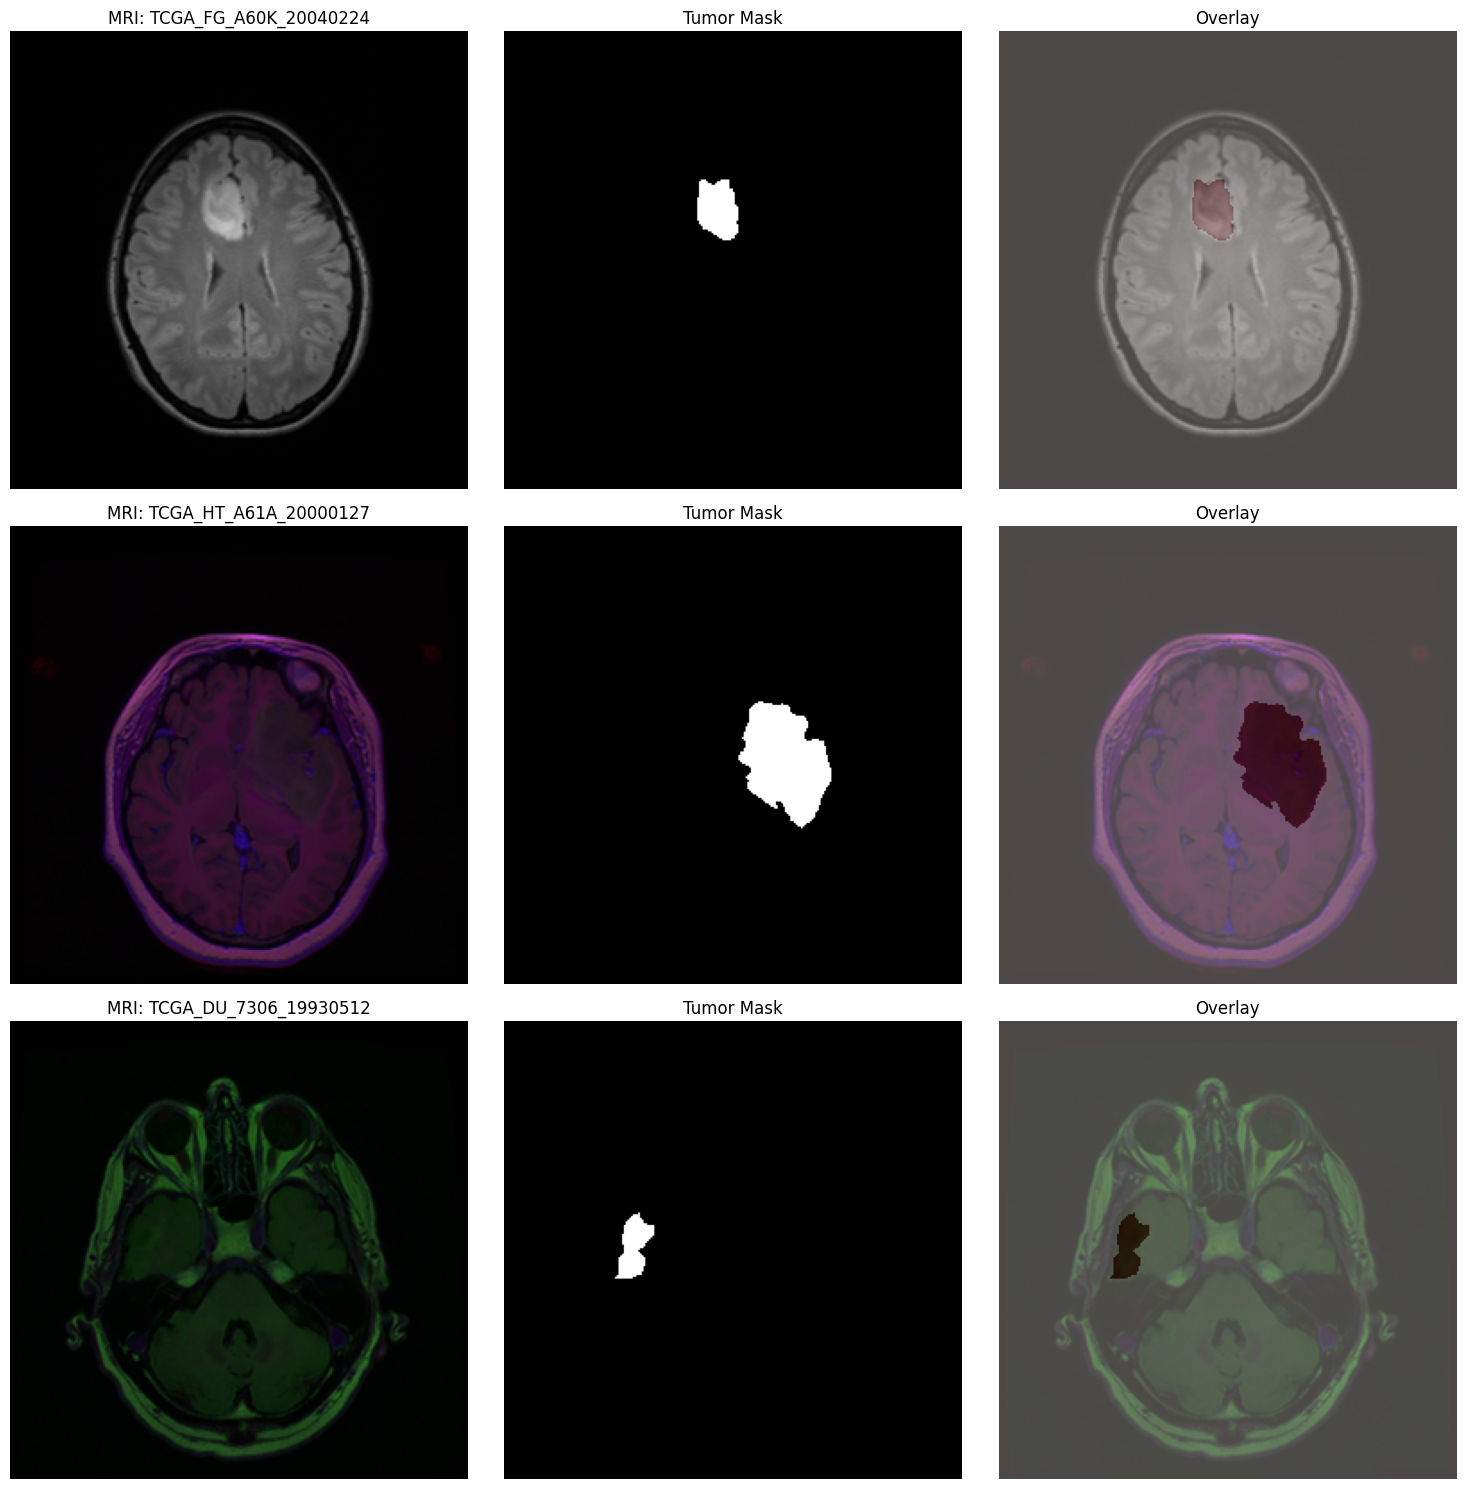

In [13]:
import matplotlib.pyplot as plt
import cv2
import random

def visualize_mri_samples(df, num_samples=3):
    # Filter for slices that actually have a tumor (mask max value > 0)
    # This ensures we aren't just looking at empty black masks
    tumor_slices = df[df['mask_path'].apply(lambda x: cv2.imread(x, 0).max() > 0)]

    # Pick random samples from the tumor slices
    samples = tumor_slices.sample(num_samples)

    plt.figure(figsize=(15, 5 * num_samples))

    for i, (idx, row) in enumerate(samples.iterrows()):
        # Load Image
        img = cv2.imread(row['image_path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Load Mask
        mask = cv2.imread(row['mask_path'], 0)

        # Plot Original MRI
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(img)
        plt.title(f"MRI: {row['patient_id']}")
        plt.axis('off')

        # Plot Mask
        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(mask, cmap='gray')
        plt.title("Tumor Mask")
        plt.axis('off')

        # Plot Overlay (MRI + Mask)
        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(img)
        plt.imshow(mask, alpha=0.3, cmap='Reds') # Overlay red mask with transparency
        plt.title("Overlay")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualization on your training set
visualize_mri_samples(train_df)

In [14]:
import torch
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np

# Also define DEVICE here to prevent the previous error from coming back
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [15]:
class Neuroseg(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['image_path']
        mask_path = self.df.iloc[idx]['mask_path']

        # 1. Read files
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.float32)

        # 2. Apply transforms
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        # 3. Final Conversion Check
        # If ToTensorV2() was used, these are already Tensors.
        # If not, we convert them here.
        if not isinstance(image, torch.Tensor):
            image = torch.from_numpy(image).float().unsqueeze(0)

        if not isinstance(mask, torch.Tensor):
            mask = torch.from_numpy(mask).float().unsqueeze(0)

        # 4. Ensure shape is (1, H, W) even if ToTensorV2 was used
        if image.ndimension() == 2:
            image = image.unsqueeze(0)
        if mask.ndimension() == 2:
            mask = mask.unsqueeze(0)

        return image, mask

In [16]:
train_dataset=Neuroseg(train_df,transform=train_transform)
val_dataset=Neuroseg(val_df,transform=val_transform)

train_loader=DataLoader(train_dataset,
                        batch_size=2,
                        shuffle=True,
                        num_workers=4,
                        pin_memory=True)

val_loader=DataLoader(val_dataset,
                      batch_size=2,
                      shuffle=False,
                      num_workers=4,
                      pin_memory=True)

print(f"Dataset established. Batch size: 16")
print(f"Sample Image shape: {train_dataset[0][0].shape}")

Dataset established. Batch size: 16
Sample Image shape: torch.Size([1, 128, 128])


In [17]:
def check_data_alignment(dataset, num_samples=3):
    plt.figure(figsize=(10, 10))
    for i in range(num_samples):
        img, msk = dataset[i]

        # Fix: If img is (3, 256, 256), take only the first channel [0, :, :]
        # Then denormalize
        if img.shape[0] == 3:
            img_to_plot = img[0, :, :].numpy() * 0.5 + 0.5
        else:
            img_to_plot = img.squeeze().numpy() * 0.5 + 0.5

        msk_to_plot = msk.squeeze().numpy()

        plt.subplot(2, num_samples, i + 1)
        plt.imshow(img_to_plot, cmap='gray')
        plt.title("MRI Scan")
        plt.axis('off')

        plt.subplot(2, num_samples, i + 1 + num_samples)
        plt.imshow(msk_to_plot, cmap='Reds', alpha=0.7)
        plt.title(f"Aligned Mask {i+1}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [18]:
import torch

# Define the device variable
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

Using device: cpu


In [19]:
import torch.nn as nn



class UNet(nn.Module):

    def __init__(self, in_channels=1, out_channels=1):

        super(UNet, self).__init__()



        def conv_block(in_c, out_c):

            return nn.Sequential(

                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),

                nn.BatchNorm2d(out_c),

                nn.ReLU(inplace=True),

                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),

                nn.BatchNorm2d(out_c),

                nn.ReLU(inplace=True)

            )



        # Encoder (Downsampling)

        self.enc1 = conv_block(in_channels, 64)

        self.enc2 = conv_block(64, 128)

        self.enc3 = conv_block(128, 256)

        self.enc4 = conv_block(256, 512)



        self.pool = nn.MaxPool2d(2)



        # Bottleneck

        self.bottleneck = conv_block(512, 1024)



        # Decoder (Upsampling)

        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)

        self.dec4 = conv_block(1024, 512) # 512 (from up) + 512 (from skip)



        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)

        self.dec3 = conv_block(512, 256)



        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)

        self.dec2 = conv_block(256, 128)



        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)

        self.dec1 = conv_block(128, 64)



        # Output Layer

        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)



    def forward(self, x):

        # Encoder

        s1 = self.enc1(x)

        p1 = self.pool(s1)

        s2 = self.enc2(p1)

        p2 = self.pool(s2)

        s3 = self.enc3(p2)

        p3 = self.pool(s3)

        s4 = self.enc4(p3)

        p4 = self.pool(s4)



        # Bottleneck

        b = self.bottleneck(p4)



        # Decoder with Skip Connections

        d4 = self.up4(b)

        d4 = torch.cat((d4, s4), dim=1) # Concatenate

        d4 = self.dec4(d4)



        d3 = self.up3(d4)

        d3 = torch.cat((d3, s3), dim=1)

        d3 = self.dec3(d3)



        d2 = self.up2(d3)

        d2 = torch.cat((d2, s2), dim=1)

        d2 = self.dec2(d2)



        d1 = self.up1(d2)

        d1 = torch.cat((d1, s1), dim=1)

        d1 = self.dec1(d1)



        return self.final_conv(d1)



# Initialize model

model = UNet(in_channels=1, out_channels=1).to(DEVICE)

print("U-Net Architecture initialized.")



U-Net Architecture initialized.


In [20]:
import torch
import torch.nn as nn
import numpy as np

# Metric calculation function (KPIs)
def get_metrics(preds, targets, threshold=0.5, smooth=1e-6):
    # Apply sigmoid if not already applied in the model
    preds = torch.sigmoid(preds)
    preds = (preds > threshold).float()
    targets = (targets > threshold).float()

    preds = preds.view(-1)
    targets = targets.view(-1)

    intersection = (preds * targets).sum()
    total = preds.sum() + targets.sum()
    union = (preds + targets).sum() - intersection

    dice = (2. * intersection + smooth) / (total + smooth)
    iou = (intersection + smooth) / (union + smooth)

    # Sensitivity/Recall
    sensitivity = (intersection + smooth) / (targets.sum() + smooth)

    return dice.item(), iou.item(), sensitivity.item()

# Specialized Loss for Segmentation
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = torch.sigmoid(preds) # Ensure values are 0-1
        preds = preds.view(-1)
        targets = targets.view(-1)

        intersection = (preds * targets).sum()
        dice = (2. * intersection + self.smooth) / (preds.sum() + targets.sum() + self.smooth)
        return 1 - dice

# Metadata calculation (Surface Area)
def calculate_tumor_area(mask, threshold=0.5):
    binary_mask = (mask > threshold).float()
    return torch.sum(binary_mask).item()

In [21]:
class CombinedLoss(nn.Module):
    def __init__(self):
        super(CombinedLoss, self).__init__()
        self.bce = nn.BCEWithLogitsLoss() # Good for pixel-level stability
        self.dice = DiceLoss()             # Good for overlap optimization

    def forward(self, preds, targets):
        return self.bce(preds, targets) + self.dice(preds, targets)

In [22]:
import cv2

def post_process_mask(mask):
    # mask: numpy array (H, W)
    kernel = np.ones((3,3), np.uint8)
    # Removes small white noise (opening)
    cleaned_mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    return cleaned_mask

In [23]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',      # we maximize Dice score
    factor=0.5,
    patience=3,
)


In [24]:
criterion = CombinedLoss()

num_epochs = 5
best_val_dice = 0.0
early_stop_counter = 0
early_stop_patience = 6


In [25]:
from tqdm import tqdm   # ← add this once

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)

criterion = CombinedLoss()

num_epochs = 5
best_val_dice = 0.0
early_stop_counter = 0
early_stop_patience = 6

for epoch in range(num_epochs):
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")

    model.train()
    train_loss = 0.0
    train_dice = 0.0

    for images, masks in tqdm(train_loader, desc="Training", leave=False):
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        dice, _, _ = get_metrics(outputs, masks)

        train_loss += loss.item()
        train_dice += dice

    train_loss /= len(train_loader)
    train_dice /= len(train_loader)

    model.eval()
    val_loss = 0.0
    val_dice = 0.0
    val_iou = 0.0
    val_sensitivity = 0.0

    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc="Validation", leave=False):
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, masks)

            dice, iou, sens = get_metrics(outputs, masks)

            val_loss += loss.item()
            val_dice += dice
            val_iou += iou
            val_sensitivity += sens

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)
    val_iou /= len(val_loader)
    val_sensitivity /= len(val_loader)

    print(f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Dice:   {val_dice:.4f}")
    print(f"Val IoU:    {val_iou:.4f} | Val Sens:  {val_sensitivity:.4f}")

    scheduler.step(val_dice)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "best_unet_model.pth")
        print("✅ Best model saved")
        early_stop_counter = 0
    else:
        early_stop_counter += 1

    if early_stop_counter >= early_stop_patience:
        print("⛔ Early stopping triggered")
        break



Epoch [1/5]


Train Loss: 1.1732 | Train Dice: 0.2446
Val Loss:   0.9995 | Val Dice:   0.4301
Val IoU:    0.3898 | Val Sens:  0.6229
✅ Best model saved

Epoch [2/5]


Train Loss: 0.9115 | Train Dice: 0.2967
Val Loss:   0.8885 | Val Dice:   0.5540
Val IoU:    0.5126 | Val Sens:  0.6290
✅ Best model saved

Epoch [3/5]


Train Loss: 0.8163 | Train Dice: 0.2928
Val Loss:   0.7963 | Val Dice:   0.5584
Val IoU:    0.4935 | Val Sens:  0.7031
✅ Best model saved

Epoch [4/5]


Train Loss: 0.7680 | Train Dice: 0.3359
Val Loss:   0.7455 | Val Dice:   0.6236
Val IoU:    0.5523 | Val Sens:  0.7153
✅ Best model saved

Epoch [5/5]


Train Loss: 0.7433 | Train Dice: 0.3542
Val Loss:   0.7752 | Val Dice:   0.6180
Val IoU:    0.5570 | Val Sens:  0.6771


In [26]:
model.load_state_dict(torch.load("best_unet_model.pth", map_location=DEVICE))
model.eval()
print("Best model (Epoch 4) loaded")


Best model (Epoch 4) loaded


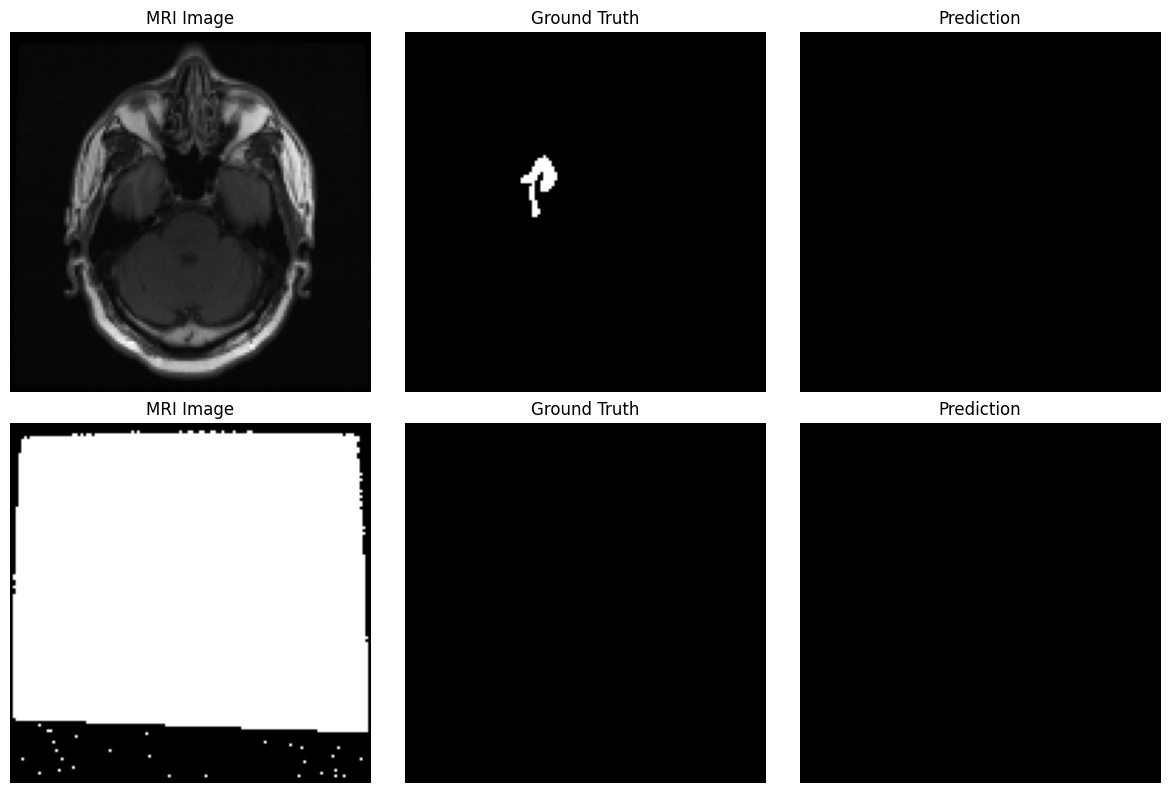

In [28]:
images, masks = next(iter(val_loader))
images = images.to(DEVICE)
masks = masks.to(DEVICE)

with torch.no_grad():
    preds = torch.sigmoid(model(images))
    preds = (preds > 0.5).float()

num_samples = images.size(0)  # <-- dynamic batch size
num_samples = min(num_samples, 3)

plt.figure(figsize=(12, 4*num_samples))

for i in range(num_samples):
    plt.subplot(num_samples, 3, 3*i + 1)
    plt.imshow(images[i][0].cpu(), cmap='gray')
    plt.title("MRI Image")
    plt.axis('off')

    plt.subplot(num_samples, 3, 3*i + 2)
    plt.imshow(masks[i][0].cpu(), cmap='gray')
    plt.title("Ground Truth")
    plt.axis('off')

    plt.subplot(num_samples, 3, 3*i + 3)
    plt.imshow(preds[i][0].cpu(), cmap='gray')
    plt.title("Prediction")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [29]:
test_dataset = Neuroseg(test_df, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)


In [30]:
test_dice = 0.0
test_iou = 0.0
test_sensitivity = 0.0
tumor_areas = []

model.eval()

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="Testing"):

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        outputs = model(images)

        dice, iou, sens = get_metrics(outputs, masks)

        test_dice += dice
        test_iou += iou
        test_sensitivity += sens

        # Tumor area calculation
        preds = torch.sigmoid(outputs)
        area = calculate_tumor_area(preds)
        tumor_areas.append(area)

# Average metrics
test_dice /= len(test_loader)
test_iou /= len(test_loader)
test_sensitivity /= len(test_loader)

print("\n🎯 TEST RESULTS")
print(f"Dice Score: {test_dice:.4f}")
print(f"IoU Score: {test_iou:.4f}")
print(f"Sensitivity: {test_sensitivity:.4f}")
print(f"Average Tumor Area: {np.mean(tumor_areas):.2f} pixels")


Testing: 100%|██████████| 71/71 [04:26<00:00,  3.75s/it]


🎯 TEST RESULTS
Dice Score: 0.4905
IoU Score: 0.3641
Sensitivity: 0.4386
Average Tumor Area: 1172.46 pixels
